# KHÁM PHÁ VÀ LÀM SẠCH DỮ LIỆU CHẤT LƯỢNG KHÔNG KHÍ

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Đọc dữ liệu

In [2]:
df = pd.read_csv("data/raw/data2225.csv")
df_raw = df.copy()
df["Local Time"] = pd.to_datetime(df["Local Time"], errors='coerce')
drop_cols = ["City", "Country Code", "Timezone", "UTC Time"]
df = df.drop(columns=drop_cols)
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])
display(df.head())

Số dòng: 34759
Số cột: 15


,Local Time,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
0,2022-01-13 07:00:00,61,353.1,10.0,84.0,98.0,17.08,52.0,100,0.00,1020,95,15.5,0.6,2.00
1,2022-01-13 08:00:00,61,343.5,9.0,87.3,95.7,16.75,48.7,91,0.00,1021,94,15.4,0.7,2.33
2,2022-01-13 09:00:00,60,334.0,8.0,90.7,93.3,16.42,45.3,83,0.50,1022,93,15.3,1.0,2.66
3,2022-01-13 10:00:00,59,324.5,7.0,94.0,91.0,16.09,42.0,75,0.75,1022,93,15.2,1.5,3.00
4,2022-01-13 11:00:00,60,319.6,6.7,95.7,91.3,16.17,39.0,83,0.00,1021,87,15.6,1.9,3.00


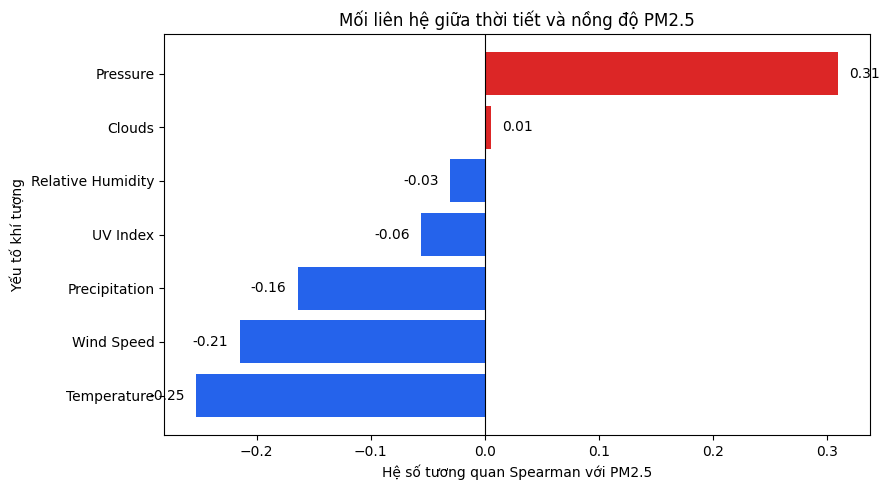

In [4]:
weather_cols = [
    "Clouds", "Precipitation", "Pressure",
    "Relative Humidity", "Temperature",
    "UV Index", "Wind Speed"
]

weather_corr = (
    eda_plot[["PM25"] + weather_cols]
    .corr(method="spearman")["PM25"]
    .drop("PM25")
    .sort_values()
)

colors = [
    "#dc2626" if value > 0 else "#2563eb"
    for value in weather_corr.values
]

plt.figure(figsize=(9, 5))
bars = plt.barh(weather_corr.index, weather_corr.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)

plt.xlabel("Hệ số tương quan Spearman với PM2.5")
plt.ylabel("Yếu tố khí tượng")
plt.title("Mối liên hệ giữa thời tiết và nồng độ PM2.5")

for bar, value in zip(bars, weather_corr.values):
    offset = 0.01 if value >= 0 else -0.01
    plt.text(
        value + offset,
        bar.get_y() + bar.get_height()/2,
        f"{value:.2f}",
        va="center",
        ha="left" if value >= 0 else "right"
    )

plt.tight_layout()
plt.show()

In [3]:
print("Dòng trùng hoàn toàn:", df.duplicated().sum())
print("Local Time bị lặp:", df["Local Time"].duplicated().sum())
print(" Bản ghi có cùng timestamp:", df["Local Time"].duplicated().sum() > 0)

Dòng trùng hoàn toàn: 0
Local Time bị lặp: 8
 Bản ghi có cùng timestamp: True


## 2. Khám phá dữ liệu ban đầu

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34759 entries, 0 to 34758
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Local Time         34759 non-null  datetime64[ns]
 1   AQI                34759 non-null  int64         
 2   CO                 34685 non-null  float64       
 3   NO2                34685 non-null  float64       
 4   O3                 34685 non-null  float64       
 5   PM10               34757 non-null  float64       
 6   PM25               34757 non-null  float64       
 7   SO2                34685 non-null  float64       
 8   Clouds             34759 non-null  int64         
 9   Precipitation      34759 non-null  float64       
 10  Pressure           34759 non-null  int64         
 11  Relative Humidity  34759 non-null  int64         
 12  Temperature        34759 non-null  float64       
 13  UV Index           34759 non-null  float64       
 14  Wind S

In [5]:
display(df.describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
AQI,34759.0,65.83,35.31,0.00,41.00,60.00,80.00,500.0
CO,34685.0,524.27,842.69,0.00,126.10,196.10,504.00,15956.2
NO2,34685.0,18.33,22.17,0.00,6.30,11.00,21.84,624.0
O3,34685.0,54.68,42.72,0.00,23.70,45.00,75.00,700.0
PM10,34757.0,42.79,43.98,0.48,19.00,30.38,51.00,604.0
PM25,34757.0,21.14,17.60,0.48,9.90,16.50,26.00,274.2
SO2,34685.0,36.31,35.10,0.00,13.44,29.82,49.00,432.6
Clouds,34759.0,68.49,32.86,0.00,45.00,78.00,100.00,100.0
Precipitation,34759.0,0.31,1.14,0.00,0.00,0.00,0.00,40.0
Pressure,34759.0,1009.91,7.19,983.00,1004.00,1010.00,1015.00,1033.0


In [6]:
missing_before = df.isna().sum()

missing_table = pd.DataFrame({
    "Số giá trị thiếu": missing_before,
    "Tỷ lệ (%)": missing_before / len(df) * 100
})

display(missing_table[missing_table["Số giá trị thiếu"] > 0].round(2))

,Số giá trị thiếu,Tỷ lệ (%)
CO,74,0.21
NO2,74,0.21
O3,74,0.21
PM10,2,0.01
PM25,2,0.01
SO2,74,0.21


## 3. Kiểm tra thời gian

In [7]:
df["Local Time"] = pd.to_datetime(df["Local Time"], errors="coerce")
df = df.sort_values("Local Time")

duplicate_rows_before = df.duplicated().sum()
duplicate_time_before = df["Local Time"].duplicated().sum()

expected_time = pd.date_range(
    df["Local Time"].min(),
    df["Local Time"].max(),
    freq="h"
)
missing_time = expected_time.difference(df["Local Time"].dropna().unique())

print("Thời gian bắt đầu:", df["Local Time"].min())
print("Thời gian kết thúc:", df["Local Time"].max())
print("Số dòng trùng hoàn toàn:", duplicate_rows_before)
print("Số bản ghi dư do trùng timestamp:", duplicate_time_before)
print("Số timestamp bị thiếu:", len(missing_time))

Thời gian bắt đầu: 2022-01-13 07:00:00
Thời gian kết thúc: 2025-12-31 23:00:00
Số dòng trùng hoàn toàn: 0
Số bản ghi dư do trùng timestamp: 8
Số timestamp bị thiếu: 18


In [8]:
duplicate_time_rows = df[df["Local Time"].duplicated(keep=False)]
display(duplicate_time_rows.sort_values("Local Time"))

,Local Time,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
18665,2024-03-01,2/29/2024 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,16,216.0,6.25,33.7,3.75,3.75,17.90,100,0.00,1020,69,14.5,0.0,2.00
18666,2024-03-01,2/29/2024 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,16,216.0,6.25,27.8,3.75,3.75,19.20,100,0.00,1020,71,14.2,0.0,2.00
19410,2024-04-01,3/31/2024 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,84,214.0,9.25,29.2,41.50,27.75,10.00,0,0.00,1002,92,25.6,0.0,2.00
19411,2024-04-01,3/31/2024 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,84,214.0,9.25,29.2,41.50,27.75,15.15,0,0.00,1001,94,24.8,0.0,1.60
24547,2024-11-01,10/31/2024 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,454.8,12.31,27.3,93.45,74.76,50.27,0,0.00,1009,97,23.7,0.0,1.20
24548,2024-11-01,10/31/2024 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,1464.7,8.69,18.6,93.45,74.76,34.02,0,0.00,1009,97,23.3,0.0,1.20
25268,2024-12-01,11/30/2024 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,84,164.4,8.11,63.7,29.95,28.00,27.85,91,0.00,1013,92,16.4,0.0,0.80
25269,2024-12-01,11/30/2024 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,89,164.4,8.11,63.7,34.02,30.38,27.85,92,0.00,1013,94,15.8,0.0,0.80
28882,2025-05-01,4/30/2025 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,90,393.7,18.50,32.1,38.15,30.50,144.00,100,0.50,1011,91,26.5,0.0,1.00
28883,2025-05-01,4/30/2025 17:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,90,230.7,18.50,36.7,38.15,30.50,36.85,100,0.50,1011,91,26.5,0.0,1.00


## 4. Làm sạch dữ liệu

In [9]:
df_clean = df.copy()

# Bỏ dòng không có thời gian
df_clean = df_clean.dropna(subset=["Local Time"])

# Bỏ các cột không dùng để phân tích
drop_cols = ["UTC Time", "City", "Country Code", "Timezone"]
df_clean = df_clean.drop(columns=drop_cols, errors="ignore")

# Chuyển các cột đo lường sang kiểu số
data_cols = df_clean.columns.drop("Local Time")
df_clean[data_cols] = df_clean[data_cols].apply(pd.to_numeric, errors="coerce")

In [10]:
local_time = pd.to_datetime(df["Local Time"], errors="coerce")
print("Bắt đầu:", local_time.min())
print("Kết thúc:", local_time.max())


Bắt đầu: 2022-01-13 07:00:00
Kết thúc: 2025-12-31 23:00:00


In [11]:
expected_time = pd.date_range(local_time.min(), local_time.max(), freq="h")
missing_time = expected_time.difference(pd.DatetimeIndex(local_time.unique()))
print("Số mốc giờ bị thiếu:", len(missing_time))


Số mốc giờ bị thiếu: 18


In [12]:
# Các biến này không nhận giá trị âm
non_negative_cols = [
    "AQI", "CO", "NO2", "O3", "PM10", "PM25", "SO2",
    "Clouds", "Precipitation", "Pressure",
    "Relative Humidity", "UV Index", "Wind Speed"
]

for col in non_negative_cols:
    df_clean.loc[df_clean[col] < 0, col] = np.nan

# Độ ẩm và độ che phủ mây nằm trong khoảng 0-100%
df_clean.loc[~df_clean["Relative Humidity"].between(0, 100), "Relative Humidity"] = np.nan
df_clean.loc[~df_clean["Clouds"].between(0, 100), "Clouds"] = np.nan

In [13]:
df_clean = df_clean.groupby("Local Time", as_index=False).mean()
df_clean = df_clean.sort_values("Local Time")

df_clean = df_clean.set_index("Local Time")
old_time = df_clean.index.copy()
df_clean = df_clean.asfreq("h")
df_clean["WasInserted"] = ~df_clean.index.isin(old_time)

print("Số timestamp được bổ sung:", df_clean["WasInserted"].sum())

Số timestamp được bổ sung: 18


In [14]:

df_clean["HadMissingValue"] = df_clean.drop(columns="WasInserted").isna().any(axis=1)

value_cols = df_clean.columns.drop(["WasInserted", "HadMissingValue"])
print("Số giá trị thiếu trước nội suy:", df_clean[value_cols].isna().sum().sum())
df_clean[value_cols] = df_clean[value_cols].interpolate(method="time",limit_area="inside")
df_clean[value_cols] = df_clean[value_cols].ffill().bfill()
df_clean = df_clean.reset_index()

Số giá trị thiếu trước nội suy: 552


## 5. Kết quả sau xử lý

In [15]:
expected_after = pd.date_range(
    df_clean["Local Time"].min(),
    df_clean["Local Time"].max(),
    freq="h"
)

print("KẾT QUẢ SAU XỬ LÝ")
print("Số dòng:", len(df_clean))
print("Số timestamp trùng:", df_clean["Local Time"].duplicated().sum())
print("Số timestamp còn thiếu:", len(expected_after.difference(df_clean["Local Time"])))
print("Số timestamp đã bổ sung:", df_clean["WasInserted"].sum())
print("Tổng số giá trị còn thiếu:", df_clean.isna().sum().sum())

KẾT QUẢ SAU XỬ LÝ
Số dòng: 34769
Số timestamp trùng: 0
Số timestamp còn thiếu: 0
Số timestamp đã bổ sung: 18
Tổng số giá trị còn thiếu: 0


In [16]:
result = pd.DataFrame({
    "Chỉ tiêu": [
        "Số dòng",
        "Bản ghi dư do trùng timestamp",
        "Timestamp bị thiếu",
        "Giá trị thiếu"
    ],
    "Trước xử lý": [
        len(df),
        duplicate_time_before,
        len(missing_time),
        df.isna().sum().sum()
    ],
    "Sau xử lý": [
        len(df_clean),
        df_clean["Local Time"].duplicated().sum(),
        len(expected_after.difference(df_clean["Local Time"])),
        df_clean.isna().sum().sum()
    ]
})

display(result)

,Chỉ tiêu,Trước xử lý,Sau xử lý
0,Số dòng,34759,34769
1,Bản ghi dư do trùng timestamp,8,0
2,Timestamp bị thiếu,18,0
3,Giá trị thiếu,300,0


## 6. Khám phá PM2.5 sau khi làm sạch

In [17]:
display(df_clean.describe().T.round(2))

,count,mean,min,25%,50%,75%,max,std
Local Time,34769,2024-01-07 15:00:00,2022-01-13 07:00:00,2023-01-10 11:00:00,2024-01-07 15:00:00,2025-01-03 19:00:00,2025-12-31 23:00:00,NaN
AQI,34769.0,65.86163,0.0,41.0,60.0,80.0,500.0,35.336484
CO,34769.0,523.65604,0.0,126.1,195.7,504.0,15956.2,841.999872
NO2,34769.0,18.33254,0.0,6.3,11.0,21.986667,624.0,22.128812
O3,34769.0,54.624894,0.0,23.7,44.8,75.0,700.0,42.68788
PM10,34769.0,42.799119,0.48,19.0,30.4,51.0,604.0,43.97939
PM25,34769.0,21.157621,0.48,9.9,16.5,26.04,274.2,17.624267
SO2,34769.0,36.292178,0.0,13.44,29.82,48.96,432.6,35.051434
Clouds,34769.0,68.485936,0.0,45.0,78.0,100.0,100.0,32.858726
Precipitation,34769.0,0.313957,0.0,0.0,0.0,0.0,40.0,1.138226


Độ lệch của PM2.5: 2.778994781336931


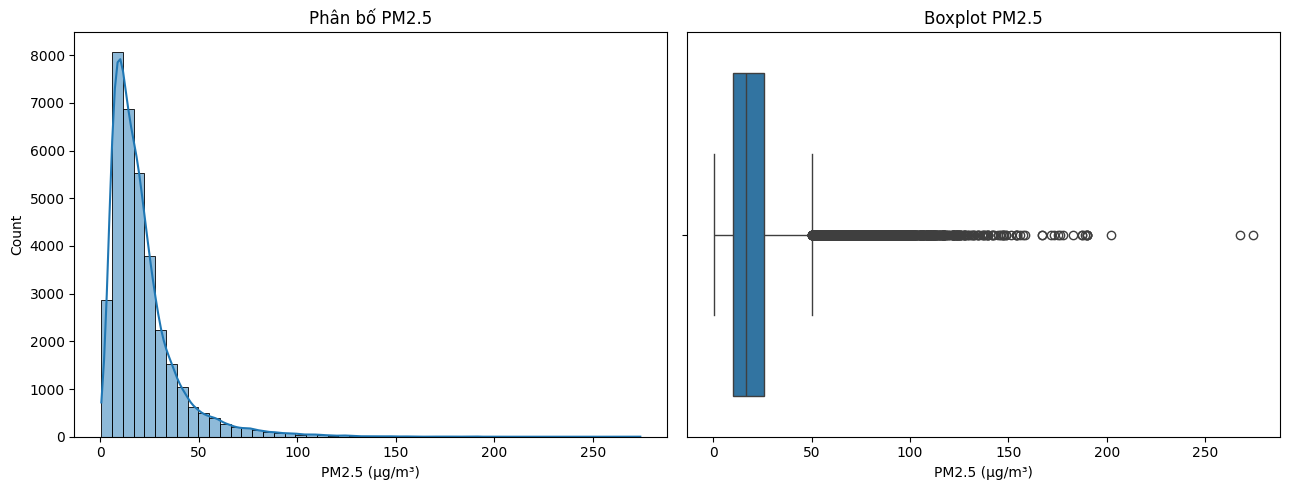

In [23]:
print("Độ lệch của PM2.5:", df["PM25"].skew())
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df_clean["PM25"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Phân bố PM2.5")
axes[0].set_xlabel("PM2.5 (µg/m³)")

sns.boxplot(x=df_clean["PM25"], ax=axes[1])
axes[1].set_title("Boxplot PM2.5")
axes[1].set_xlabel("PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()


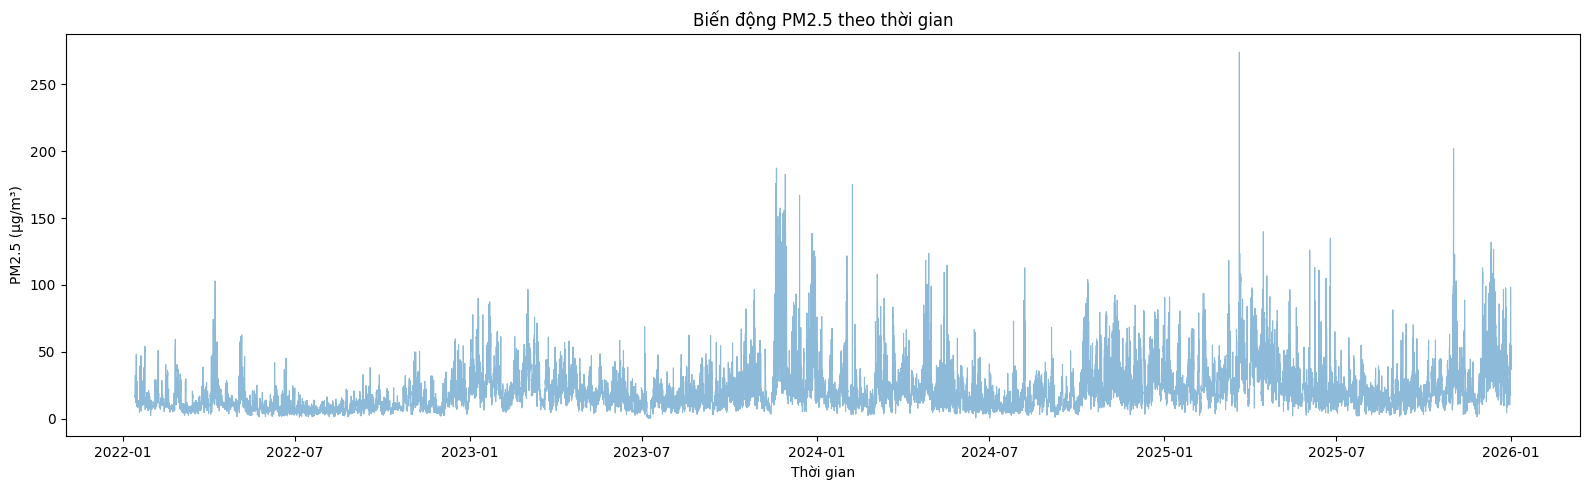

In [19]:
plt.figure(figsize=(16, 5))
plt.plot(df_clean["Local Time"], df_clean["PM25"], alpha=0.5, linewidth=0.8)
plt.title("Biến động PM2.5 theo thời gian")
plt.xlabel("Thời gian")
plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()

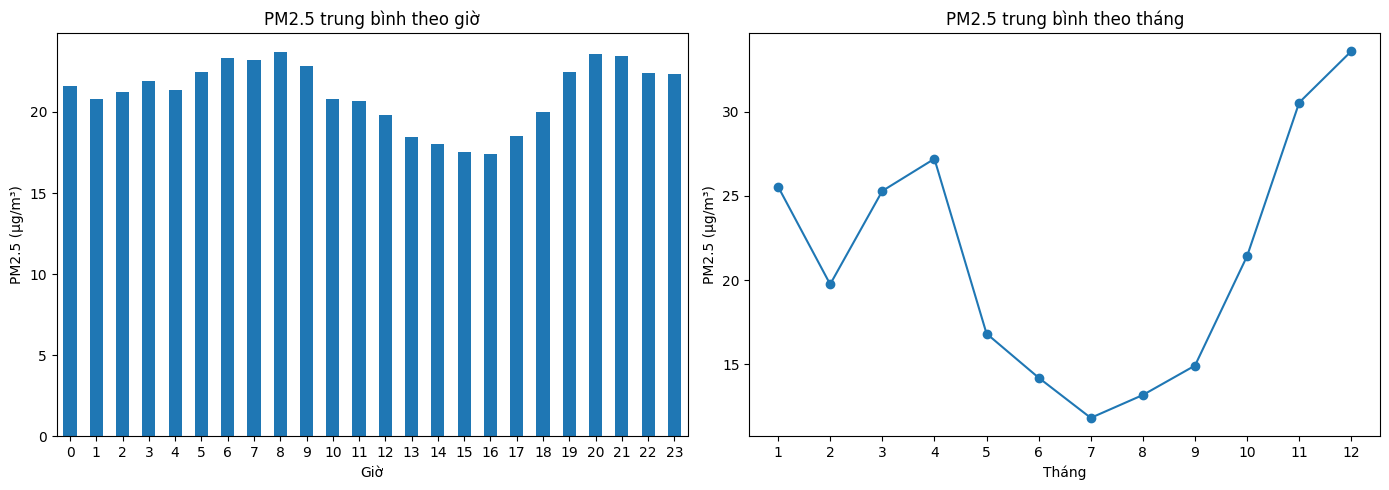

In [20]:
df_clean["Hour"] = df_clean["Local Time"].dt.hour
df_clean["Month"] = df_clean["Local Time"].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clean.groupby("Hour")["PM25"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("PM2.5 trung bình theo giờ")
axes[0].set_xlabel("Giờ")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].tick_params(axis="x", rotation=0)

df_clean.groupby("Month")["PM25"].mean().plot(marker="o", ax=axes[1])
axes[1].set_title("PM2.5 trung bình theo tháng")
axes[1].set_xlabel("Tháng")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

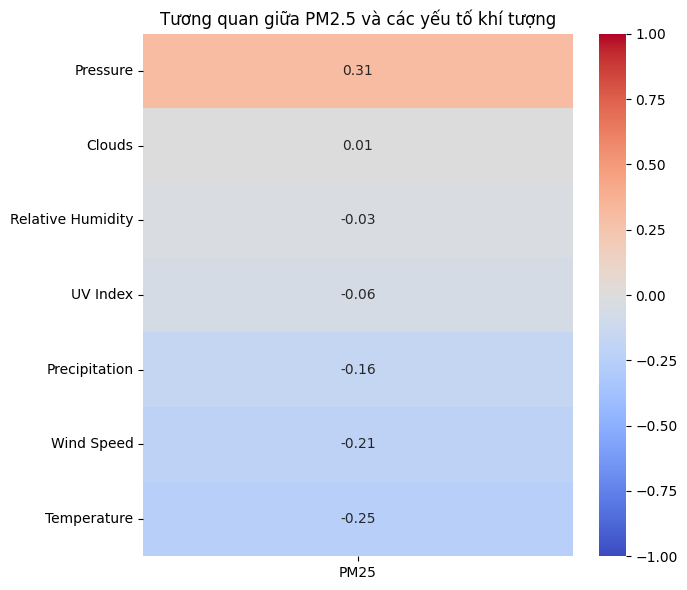

In [21]:
weather_cols = [
    "Pressure", "Clouds", "Relative Humidity",
    "UV Index", "Precipitation", "Wind Speed", "Temperature"
]

weather_corr = (
    df_clean[["PM25"] + weather_cols]
    .corr(method="spearman")[["PM25"]]
    .drop(index="PM25")
    .sort_values("PM25", ascending=False)
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    weather_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Tương quan giữa PM2.5 và các yếu tố khí tượng")
plt.tight_layout()
plt.show()

## 7. Dữ liệu dùng cho mô hình

In [22]:
model_df = df_clean.drop(
    columns=["WasInserted", "HadMissingValue"],
    errors="ignore"
)

display(model_df.head())

,Local Time,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed,Hour,Month
0,2022-01-13 07:00:00,61.0,353.1,10.0,84.0,98.0,17.08,52.0,100.0,0.00,1020.0,95.0,15.5,0.6,2.00,7,1
1,2022-01-13 08:00:00,61.0,343.5,9.0,87.3,95.7,16.75,48.7,91.0,0.00,1021.0,94.0,15.4,0.7,2.33,8,1
2,2022-01-13 09:00:00,60.0,334.0,8.0,90.7,93.3,16.42,45.3,83.0,0.50,1022.0,93.0,15.3,1.0,2.66,9,1
3,2022-01-13 10:00:00,59.0,324.5,7.0,94.0,91.0,16.09,42.0,75.0,0.75,1022.0,93.0,15.2,1.5,3.00,10,1
4,2022-01-13 11:00:00,60.0,319.6,6.7,95.7,91.3,16.17,39.0,83.0,0.00,1021.0,87.0,15.6,1.9,3.00,11,1
